# Identifying Hardware Failure Patterns in Amazon PC Reviews Using NLP

This project analyzes Amazon PC product reviews to identify the most common hardware issues mentioned in negative customer feedback. Natural Language Processing (NLP) techniques such as text cleaning, keyword extraction, and topic modeling are used to uncover patterns in customer complaints.

## 1. Load Amazon PC Reviews Dataset

In [2]:
import pandas as pd

data = pd.read_csv(
    "amazon_reviews_us_PC_v1_00.tsv",
    sep="\t",
    nrows=100000,
    on_bad_lines="skip"
)

data.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,22873041,R3ARRMDEGED8RD,B00KJWQIIC,335625766,Plemo 14-Inch Laptop Sleeve Case Waterproof Fa...,PC,5,0,0,N,Y,Pleasantly surprised,I was very surprised at the high quality of th...,2015-08-31
1,US,30088427,RQ28TSA020Y6J,B013ALA9LA,671157305,TP-Link OnHub AC1900 Wireless Wi-Fi Router,PC,5,24,31,N,N,OnHub is a pretty no nonsense type router that...,I am a Google employee and had to chance to us...,2015-08-31
2,US,20329786,RUXJRZCT6953M,B00PML2GQ8,982036237,AmazonBasics USB 3.0 A Male to A Male Cable - ...,PC,1,2,2,N,N,None of them worked. No functionality at all.,"Bought cables in 3ft, 6ft and 9ft. NONE of th...",2015-08-31
3,US,14215710,R7EO0UO6BPB71,B001NS0OZ4,576587596,Transcend P8 15-in-1 USB 2.0 Flash Memory Card...,PC,1,0,0,N,Y,just keep searching.,"nope, cheap and slow",2015-08-31
4,US,38264512,R39NJY2YJ1JFSV,B00AQMTND2,964759214,Aleratec SATA Data Cable 2.0 20in Serial ATA S...,PC,5,0,0,N,Y,Five Stars,Excellent! Great value and does the job.,2015-08-31


## 2. Inspect Dataset Structure

In [3]:
data.columns

Index(['marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_body', 'review_date'],
      dtype='object')

## 3. Explore Rating Distribution

In [4]:
data['star_rating'].value_counts()

star_rating
5    62472
4    14398
1    11395
3     6724
2     5011
Name: count, dtype: int64

## 4. Extract Negative Reviews

In [5]:
negative_reviews = data[data['star_rating'] <= 2]

negative_reviews.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
2,US,20329786,RUXJRZCT6953M,B00PML2GQ8,982036237,AmazonBasics USB 3.0 A Male to A Male Cable - ...,PC,1,2,2,N,N,None of them worked. No functionality at all.,"Bought cables in 3ft, 6ft and 9ft. NONE of th...",2015-08-31
3,US,14215710,R7EO0UO6BPB71,B001NS0OZ4,576587596,Transcend P8 15-in-1 USB 2.0 Flash Memory Card...,PC,1,0,0,N,Y,just keep searching.,"nope, cheap and slow",2015-08-31
8,US,50728290,R23AICGEDAJQL1,B0098Y77OG,177098042,Acer,PC,1,0,0,N,Y,You get what you pay for,"After exactly 45 days, the screen went dark. P...",2015-08-31
10,US,52027882,RC9AW4HKJ016M,B0091ITP0S,977217357,HDE Rotating iPad Case Magnetic Folding Leathe...,PC,1,0,0,N,Y,One Star,IT HAS ALREADY CRACKED AT ONE OF THE CORNERS.,2015-08-31
11,US,41770239,R2ALWJE9N6ZBXD,B008I21EA2,295632907,Linksys AC1750 Wi-Fi Wireless Dual-Band+ Route...,PC,1,0,0,N,N,Very Disappointed,Very disappointed the range of the router is v...,2015-08-31


In [6]:
negative_reviews.shape

(16406, 15)

### Negative Review Filtering

To understand the primary sources of customer dissatisfaction, we focus on reviews with a star rating of **2 or below**. These reviews represent negative customer experiences and often contain descriptions of product defects, hardware failures, or usability issues.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(negative_reviews['review_body'].astype(str))

word_counts = X.sum(axis=0)

words = vectorizer.get_feature_names_out()

import pandas as pd
complaints = pd.DataFrame({
    'word': words,
    'count': word_counts.tolist()[0]
})

complaints.sort_values(by='count', ascending=False)

,word,count
2,br,8980
18,work,4011
0,34,3293
11,just,2943
14,product,2768
17,use,2636
4,case,2135
16,time,2096
6,did,2035
13,like,2005


## 5. Keyword Extraction

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text

# default stopwords
stop_words = text.ENGLISH_STOP_WORDS

# extra useless words
custom_words = [
'just','use','using','used','like','did','does','time','product',
'buy','bought','good','work','working','case','really','even'
]

# combine and convert to list
stop_words = list(stop_words.union(custom_words))

vectorizer = CountVectorizer(
    stop_words=stop_words,
    max_features=20,
    min_df=50
)

X = vectorizer.fit_transform(negative_reviews['clean_review'])

word_counts = X.sum(axis=0)

words = vectorizer.get_feature_names_out()

complaints = pd.DataFrame({
    'word': words,
    'count': word_counts.tolist()[0]
})

complaints.sort_values(by='count', ascending=False)

,word,count
5,don,1851
1,computer,1790
11,laptop,1739
17,screen,1597
13,months,1507
4,doesn,1507
3,didn,1498
19,worked,1492
6,drive,1456
0,battery,1444


## 6. Topic Modeling

In [13]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=4, random_state=42)

lda.fit(X)

terms = vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx+1}:")
    print([terms[i] for i in topic.argsort()[-8:]])
    print()

Topic 1:
['don', 'got', 'fit', 'return', 'money', 'laptop', 'doesn', 'screen']

Topic 2:
['screen', 'don', 'months', 'got', 'laptop', 'new', 'keyboard', 'battery']

Topic 3:
['new', 'screen', 'got', 'don', 'device', 'tablet', 'drive', 'computer']

Topic 4:
['don', 'return', 'got', 'great', 'mouse', 'months', 'worked', 'didn']



## 7. Complaint Keyword Visualization

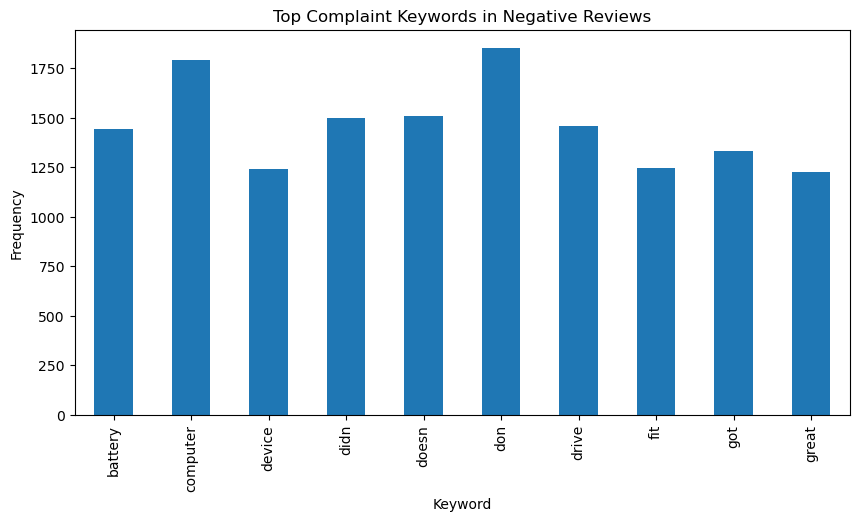

In [14]:
import matplotlib.pyplot as plt

complaints.head(10).plot(
    x='word',
    y='count',
    kind='bar',
    figsize=(10,5),
    legend=False
)

plt.title("Top Complaint Keywords in Negative Reviews")
plt.ylabel("Frequency")
plt.xlabel("Keyword")
plt.show()

In [15]:
plt.savefig("complaint_keywords_chart.png")

<Figure size 640x480 with 0 Axes>

In [22]:
!pip install wordcloud

## 8. Word Cloud Visualization

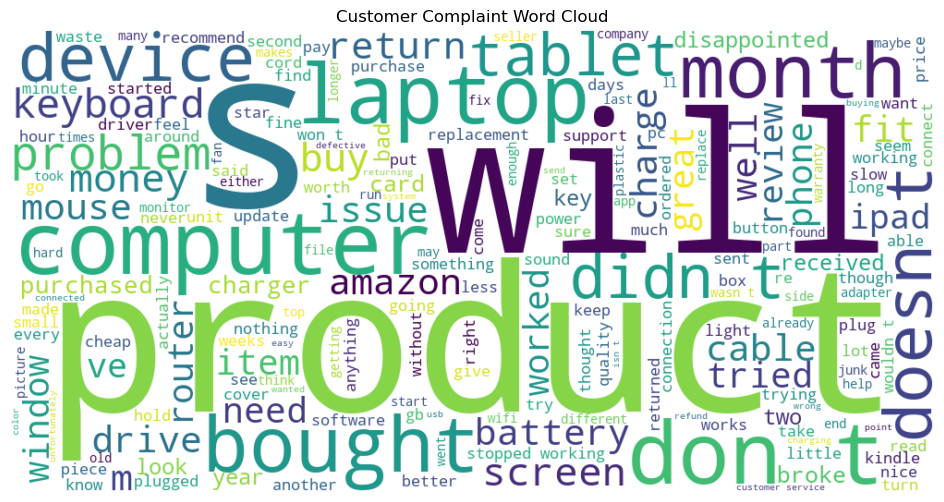

In [23]:
from wordcloud import WordCloud, STOPWORDS

extra_stopwords = {
"one","work","case","thing","make","even","still","really",
"get","got","now","new","say","back","good","use","using",
"used","way","first","week","day","time"
}

stopwords = STOPWORDS.union(extra_stopwords)

text = " ".join(negative_reviews["clean_review"].astype(str))

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis",
    stopwords=stopwords
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Customer Complaint Word Cloud")
plt.show()

In [24]:
plt.savefig("complaint_wordcloud.png")

<Figure size 640x480 with 0 Axes>

## 9. Hardware Issue Frequency Analysis

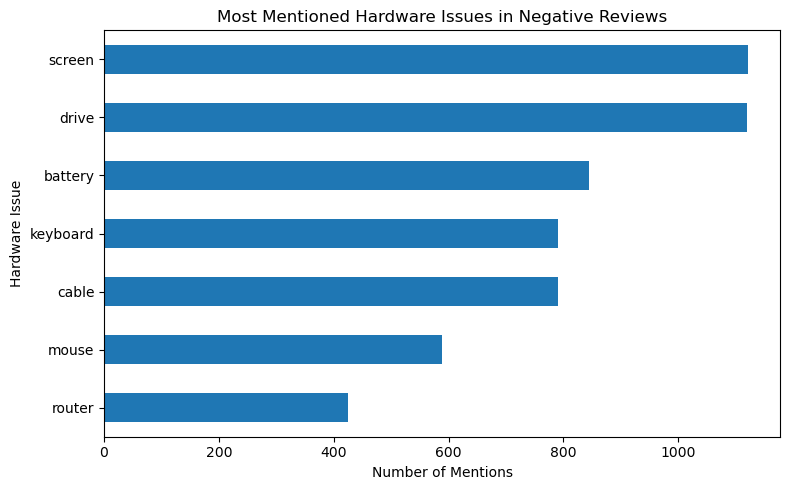

In [26]:
import pandas as pd

issue_counts = pd.Series(counts).sort_values(ascending=True)

plt.figure(figsize=(8,5))
issue_counts.plot(kind="barh")

plt.title("Most Mentioned Hardware Issues in Negative Reviews")
plt.xlabel("Number of Mentions")
plt.ylabel("Hardware Issue")

plt.tight_layout()
plt.show()

### Hardware Complaint Analysis

The frequency analysis of hardware-related keywords in negative reviews shows that **screens and storage drives** are the most frequently mentioned issues. Battery problems also appear prominently, suggesting that reliability of core device components plays a major role in negative customer experiences for PC-related products.

Peripheral devices such as routers and mice appear less frequently in complaint reviews, indicating that major dissatisfaction is primarily associated with core hardware components rather than accessories.

In [27]:
plt.savefig("hardware_complaints.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## 11. Key Insights and Conclusion

This analysis examined negative customer reviews from Amazon PC product listings to understand the primary sources of dissatisfaction.

The results indicate that **core hardware components such as screens, storage drives, and batteries** are the most commonly reported issues in negative reviews.

Topic modeling further revealed that many complaints are related to **device reliability, product defects, and return experiences**.

Overall, improving the durability and reliability of critical hardware components could significantly reduce negative customer experiences in PC-related products.